# Лабораторная работа №2
## Стохастические методы оптимизации
Продвинутые методы оптимизации — ИТМО, 2026

## Блок 0 — Настройка

In [1]:
import os, sys, random
import numpy as np
import matplotlib.pyplot as plt

def seed_everything(s=42):
    random.seed(s); np.random.seed(s)
seed_everything()

IMG_DIR = 'img'
os.makedirs(IMG_DIR, exist_ok=True)

sys.path.insert(0, 'src')
from functions     import make_rastrigin, make_ackley, make_desmos
from optimizers    import simulated_annealing, particle_swarm, memory_bytes
from lab1_optimizers import nelder_mead, gradient_descent_armijo
from utils         import run_timed, track_eps, plot_convergence, \
                          plot_function_2d, plot_trajectory, summary_table
from constructive_number import ConstructiveNumber

print("OK")


OK


## Блок 1 — Тестовые функции

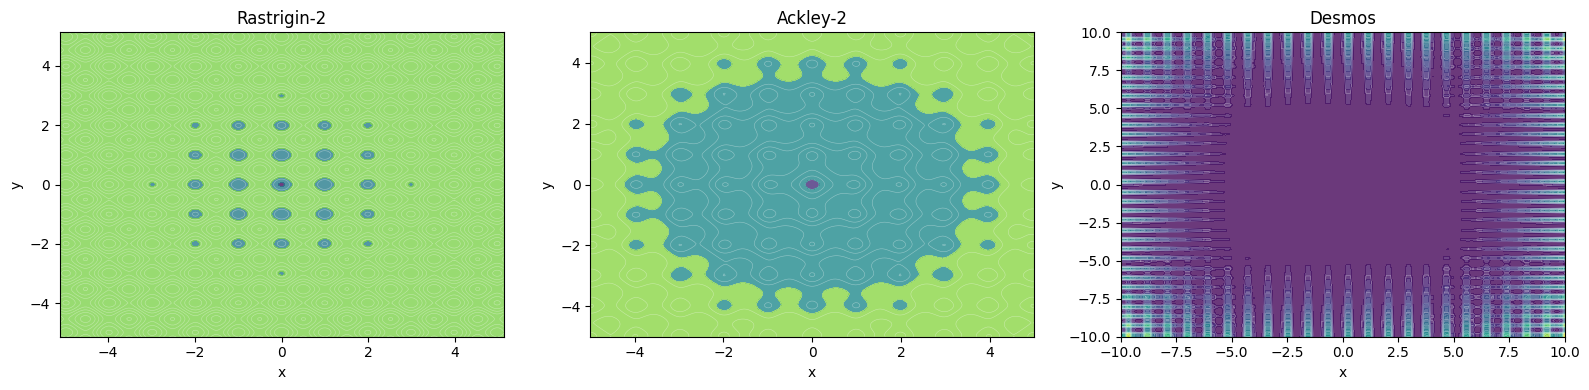

Rastrigin глоб. минимум: 0.0
Ackley    глоб. минимум: 0.0


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

f_ras = make_rastrigin()
f_ack = make_ackley()
f_des = make_desmos()

plot_function_2d(f_ras._func, f_ras.bounds, "Rastrigin-2", ax=axes[0], log_scale=True)
plot_function_2d(f_ack._func, f_ack.bounds, "Ackley-2",    ax=axes[1], log_scale=True)
plot_function_2d(f_des._func, f_des.bounds, "Desmos",      ax=axes[2])

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "functions.png"), dpi=120)
plt.show()
print("Rastrigin глоб. минимум:", f_ras([0.0, 0.0]))
print("Ackley    глоб. минимум:", float(f_ack([0.0, 0.0])))


## Блок 2 — Simulated Annealing

In [3]:
# Параметры SA
SA_PARAMS = dict(T0=10.0, alpha=0.995, n_iter=10_000, sigma=1.0, tol=1e-6)

seed_everything(42)
f_ras = make_rastrigin()
h_sa_ras, t_sa_ras = run_timed(
    simulated_annealing, f_ras, [4.0, 4.0],
    bounds=f_ras.bounds, **SA_PARAMS, seed=42
)

f_ack = make_ackley()
h_sa_ack, t_sa_ack = run_timed(
    simulated_annealing, f_ack, [4.0, 4.0],
    bounds=f_ack.bounds, **SA_PARAMS, seed=42
)

f_des = make_desmos()
h_sa_des, t_sa_des = run_timed(
    simulated_annealing, f_des, [0.0, 0.0],
    bounds=f_des.bounds, T0=50.0, alpha=0.997, n_iter=20_000, sigma=1.5, tol=1e-4, seed=42
)

for name, hist, t in [("Rastrigin", h_sa_ras, t_sa_ras),
                       ("Ackley",    h_sa_ack, t_sa_ack),
                       ("Desmos",    h_sa_des, t_sa_des)]:
    last = hist[-1]
    print(f"{name:<12} iter={last['iter']:>6}, f={last['f']:.4e}, T={last['T']:.4f}, t={t:.1f}ms")


Rastrigin    iter= 10000, f=1.8998e-02, T=0.0000, t=334.1ms
Ackley       iter= 10000, f=3.3357e-02, T=0.0000, t=274.5ms
Desmos       iter= 20000, f=1.8331e-02, T=0.0000, t=633.2ms


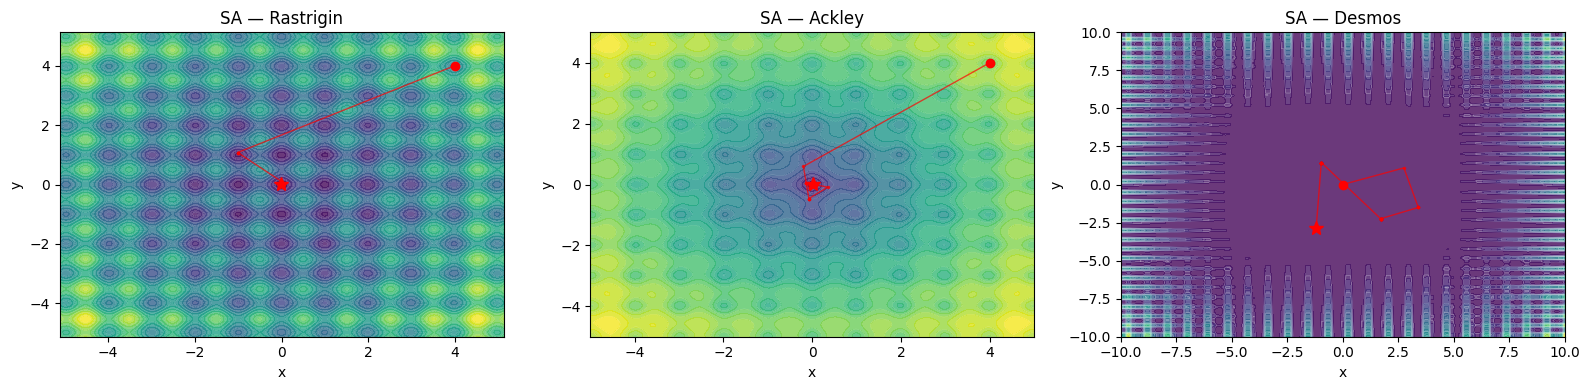

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, f_raw, hist, name in [
    (axes[0], make_rastrigin(), h_sa_ras, "SA — Rastrigin"),
    (axes[1], make_ackley(),    h_sa_ack, "SA — Ackley"),
    (axes[2], make_desmos(),    h_sa_des, "SA — Desmos"),
]:
    plot_function_2d(f_raw._func, f_raw.bounds, name, ax=ax)
    plot_trajectory(hist[::max(1, len(hist)//200)], "SA", ax, color='red')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "sa_trajectories.png"), dpi=120)
plt.show()


## Блок 3 — Particle Swarm

In [5]:
PSO_PARAMS = dict(n_particles=30, n_iter=500, w=0.7, c1=1.5, c2=1.5, tol=1e-6)

f_ras = make_rastrigin()
h_pso_ras, t_pso_ras = run_timed(
    particle_swarm, f_ras, f_ras.bounds, **PSO_PARAMS, seed=42
)

f_ack = make_ackley()
h_pso_ack, t_pso_ack = run_timed(
    particle_swarm, f_ack, f_ack.bounds, **PSO_PARAMS, seed=42
)

f_des = make_desmos()
h_pso_des, t_pso_des = run_timed(
    particle_swarm, f_des, f_des.bounds,
    n_particles=50, n_iter=1000, w=0.7, c1=1.5, c2=1.5, tol=1e-4, seed=42
)

for name, hist, t in [("Rastrigin", h_pso_ras, t_pso_ras),
                       ("Ackley",    h_pso_ack, t_pso_ack),
                       ("Desmos",    h_pso_des, t_pso_des)]:
    last = hist[-1]
    print(f"{name:<12} iter={last['iter']:>6}, f={last['f']:.4e}, t={t:.1f}ms")


Rastrigin    iter=    71, f=5.6537e-07, t=22.1ms
Ackley       iter=   114, f=9.8080e-07, t=34.4ms
Desmos       iter=  1000, f=4.2471e-02, t=293.7ms


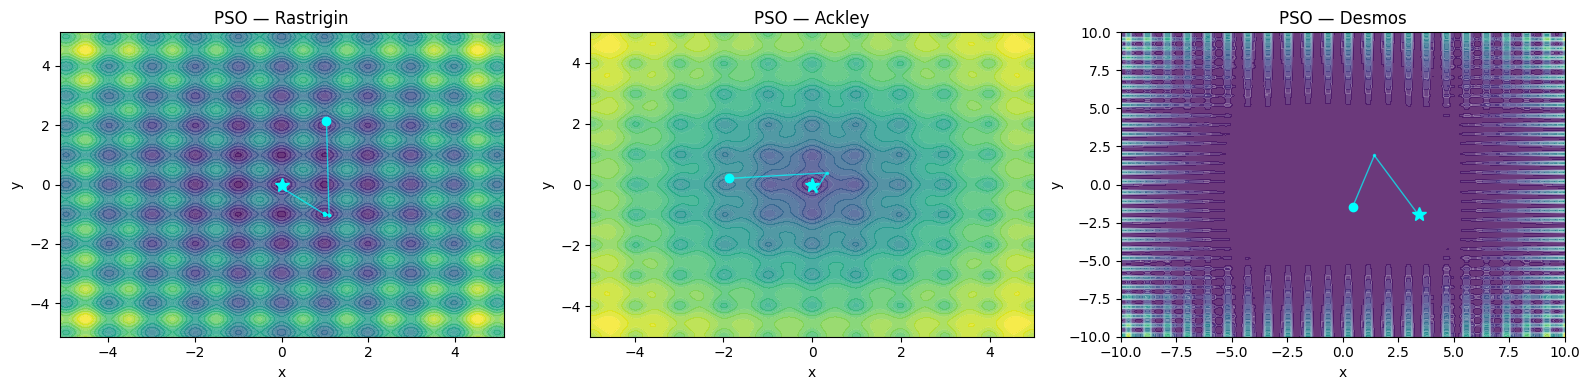

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, f_raw, hist, name in [
    (axes[0], make_rastrigin(), h_pso_ras, "PSO — Rastrigin"),
    (axes[1], make_ackley(),    h_pso_ack, "PSO — Ackley"),
    (axes[2], make_desmos(),    h_pso_des, "PSO — Desmos"),
]:
    plot_function_2d(f_raw._func, f_raw.bounds, name, ax=ax)
    # Показываем финальный рой (последние позиции не сохраняем — покажем лучшую траекторию)
    plot_trajectory(hist[::max(1, len(hist)//200)], "PSO", ax, color='cyan')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "pso_trajectories.png"), dpi=120)
plt.show()


## Блок 4 — Полное сравнение

In [7]:
# Запускаем все методы на всех функциях
# NM и GDA из лаб. 1 включены для сравнения
# GDA недоступна для Desmos (нет градиента)

results = {}
N_DIM = 2

def _run(label, method_fn, f, *args, method_name, **kwargs):
    f.reset_counters()
    h, t = run_timed(method_fn, f, *args, **kwargs)
    last = h[-1]
    results[label] = {
        'f':         last['f'],
        'iters':     last['iter'],
        'f_calls':   f.n_func_calls,
        'time_ms':   t,
        'mem_bytes': memory_bytes(method_name, N_DIM),
    }

# Rastrigin
x0 = [4.0, 4.0]
_run("NM  / Rastrigin", nelder_mead, make_rastrigin(), x0, method_name='NM', tol=1e-6, max_iter=5000)
_run("GDA / Rastrigin", gradient_descent_armijo, make_rastrigin(), x0, method_name='GDA', tol=1e-6, max_iter=5000)
_run("SA  / Rastrigin", simulated_annealing, make_rastrigin(), x0, method_name='SA',
     bounds=make_rastrigin().bounds, T0=10., alpha=0.995, n_iter=10000, sigma=1., tol=1e-6, seed=42)
_run("PSO / Rastrigin", particle_swarm, make_rastrigin(), make_rastrigin().bounds, method_name='PSO',
     n_particles=30, n_iter=500, tol=1e-6, seed=42)

# Ackley
_run("NM  / Ackley", nelder_mead, make_ackley(), x0, method_name='NM', tol=1e-6, max_iter=5000)
_run("GDA / Ackley", gradient_descent_armijo, make_ackley(), x0, method_name='GDA', tol=1e-6, max_iter=5000)
_run("SA  / Ackley", simulated_annealing, make_ackley(), x0, method_name='SA',
     bounds=make_ackley().bounds, T0=10., alpha=0.995, n_iter=10000, sigma=1., tol=1e-6, seed=42)
_run("PSO / Ackley", particle_swarm, make_ackley(), make_ackley().bounds, method_name='PSO',
     n_particles=30, n_iter=500, tol=1e-6, seed=42)

# Desmos (без GDA — нет градиента)
x0_d = [0.0, 0.0]
_run("NM  / Desmos", nelder_mead, make_desmos(), x0_d, method_name='NM', tol=1e-4, max_iter=5000)
_run("SA  / Desmos", simulated_annealing, make_desmos(), x0_d, method_name='SA',
     bounds=make_desmos().bounds, T0=50., alpha=0.997, n_iter=20000, sigma=1.5, tol=1e-4, seed=42)
_run("PSO / Desmos", particle_swarm, make_desmos(), make_desmos().bounds, method_name='PSO',
     n_particles=50, n_iter=1000, tol=1e-4, seed=42)

summary_table(results)


Метод / Функция                f*       Итер    f calls     Время,мс     Память,Б
────────────────────────────────────────────────────────────────────────────
NM  / Rastrigin        3.1838e+01         21        126          2.5           48
GDA / Rastrigin        0.0000e+00          1         12          0.1           32
SA  / Rastrigin        1.8998e-02      10000      30003         98.7           32
PSO / Rastrigin        5.6537e-07         71       6480         20.4         1456
NM  / Ackley           1.0998e+01         21        126          2.6           48
GDA / Ackley           9.7294e+00       4999     764853       3481.2           32
SA  / Ackley           3.3357e-02      10000      30003         79.4           32
PSO / Ackley           9.8080e-07        114      10350         11.7         1456
NM  / Desmos           6.1893e+01        106        636         14.3           48
SA  / Desmos           1.8331e-02      20000      60003        200.8           32
PSO / Desmos         

## Блок 5 — Анализ ε

SA Rastrigin ε₀=1e-01: start=1.417e+01, end=1.259e+01
SA Rastrigin ε₀=1e-03: start=1.417e-01, end=1.258e-01
SA Rastrigin ε₀=1e-06: start=1.417e-04, end=1.258e-04


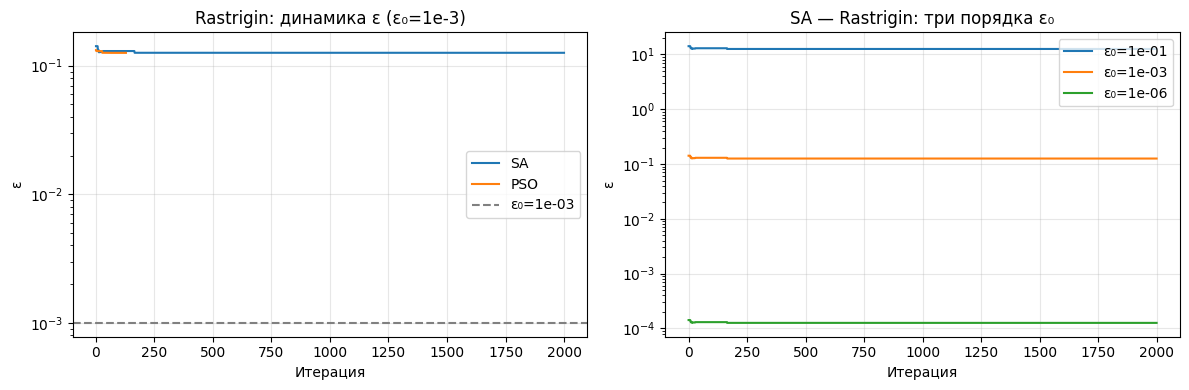

In [8]:
EPS0 = 1e-3

# SA на Rastrigin
f_ras = make_rastrigin()
h_sa = simulated_annealing(f_ras, [4.,4.], bounds=f_ras.bounds,
                            T0=10., alpha=0.995, n_iter=2000, sigma=1., seed=42)
# PSO на Rastrigin (берём историю gbest)
f_ras2 = make_rastrigin()
h_pso = particle_swarm(f_ras2, f_ras2.bounds, n_particles=30, n_iter=200, seed=42)

eps_sa  = track_eps(f_ras._func,  h_sa,  EPS0)
eps_pso = track_eps(f_ras2._func, h_pso, EPS0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(eps_sa,  label='SA')
axes[0].semilogy(eps_pso, label='PSO')
axes[0].axhline(EPS0, color='gray', linestyle='--', label=f'ε₀={EPS0:.0e}')
axes[0].set_title("Rastrigin: динамика ε (ε₀=1e-3)")
axes[0].set_xlabel("Итерация"); axes[0].set_ylabel("ε")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Сравнение трёх порядков ε₀ на SA/Rastrigin
for eps0 in [1e-1, 1e-3, 1e-6]:
    f_t = make_rastrigin()
    h_t = simulated_annealing(f_t, [4.,4.], bounds=f_t.bounds,
                               T0=10., alpha=0.995, n_iter=2000, sigma=1., seed=42)
    eps_t = track_eps(f_t._func, h_t, eps0)
    axes[1].semilogy(eps_t, label=f'ε₀={eps0:.0e}')
    print(f"SA Rastrigin ε₀={eps0:.0e}: start={eps_t[0]:.3e}, end={eps_t[-1]:.3e}")

axes[1].set_title("SA — Rastrigin: три порядка ε₀")
axes[1].set_xlabel("Итерация"); axes[1].set_ylabel("ε")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "eps_analysis.png"), dpi=120)
plt.show()
